# Barra_frets — monthly Barra factor WLS

Lazy cross-sectional weighted least squares of `ret` on Barra style + industry
exposures, one regression per `date` (month).

**Input:** `./parquet_files/fexp_panel.parquet` (from `fexp_panel2_parquet.ipynb`)  
**Output:** monthly betas (+ optional fit statistics)  
**Script:** `barra_frets.py` — same logic, runnable from the CLI

- Weight: `regwt = 1 / srisk²`
- No intercept (`WORLD` ≡ 1 for all names)
- `country_gem4 == "USA"` filter is a pushdown placeholder on the lazy scan

**Performance:** Fit statistics (`sse`, `tss`, `r2`) are **off by default** (`INCLUDE_STATS = False`).
Enabling them runs a second WLS pass per month (residuals) and roughly doubles regression time.

**Kernel:** select **`plfrets (.venv)`** in the kernel picker. The main WLS `collect()` cell takes ~10s.
Run the connectivity cell first if the kernel was recently restarted.

In [1]:
# Connectivity check — should print immediately after kernel start
import sys
print(sys.executable)
print("kernel ok")

c:\Users\algertp\cursorprojects\plfrets\.venv\Scripts\python.exe
kernel ok


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import polars_ols  # noqa: F401 — registers .least_squares namespace

PARQUET_PATH = Path("parquet_files/fexp_panel.parquet")
OUTPUT_PATH = Path("parquet_files/fexp_wls_betas.parquet")

INCLUDE_STATS = False  # set True for sse / tss / r2 (slower: second WLS pass per month)
TRAIL_MONTHS = 36  # trailing 3-year window for plot

RISK_FACTORS = [
    "WORLD", "BETA", "BTOP", "DIVYILD", "EARNQLTY", "EARNVAR", "EARNYILD",
    "GROWTH", "INVSQLTY", "LEVERAGE", "LIQUIDTY", "LTREVRSL", "MIDCAP",
    "MOMENTUM", "PROFIT", "RESVOL", "SIZE",
]

INDUSTRY_FACTORS = [
    "AEROSPCE", "AIRLINES", "DIVMETAL", "AUTOCOMP", "BANKS", "BIOTECH",
    "BLDCNSTR", "CHEMICAL", "COMMSVCS", "COMMUNIC", "COMPUTER", "CONSTPP",
    "CONSDUR", "CONSVCS", "DIVFIN", "ENERGY", "AGROCHEM", "FOODPRD", "FOODRETL",
    "GOLD", "HLTHEQP", "HLTHSVC", "HSHLDPRD", "INOILGAS", "INSURNCE", "INTERNET",
    "SOFTWARE", "MACHINRY", "MEDIA", "OILGAS", "OILEXPL", "PHARMA", "PRECMETL",
    "REALEST", "RETAIL", "SEMICOND", "SMICNDEQ", "STEEL", "TELECOM", "TRNSPORT",
    "UTILITY", "CAPMRKTS", "RGNLBNKS", "THRIFTS", "RLESTMNG",
]

PLOT_FACTORS = ["MOMENTUM", "BETA", "RESVOL", "SIZE", "EARNYILD"]

FACTOR_COLUMNS = RISK_FACTORS + INDUSTRY_FACTORS
print(f"{len(RISK_FACTORS)} style + {len(INDUSTRY_FACTORS)} industry = {len(FACTOR_COLUMNS)} factors")

11 style + 45 industry = 56 factors


In [7]:
SHOW_PLAN = False  # True prints a large query plan and can freeze the notebook UI

def wls_expr(features: list[str], mode: str, *, add_intercept: bool = False) -> pl.Expr:
    return pl.col("ret").least_squares.wls(
        *[pl.col(name) for name in features],
        sample_weights=pl.col("regwt"),
        add_intercept=add_intercept,
        null_policy="drop",
        solve_method="svd",
        mode=mode,
    )


weighted_mean_ret = (pl.col("ret") * pl.col("regwt")).sum() / pl.col("regwt").sum()

agg_exprs: list[pl.Expr] = [
    pl.len().alias("n_obs"),
    wls_expr(FACTOR_COLUMNS, "coefficients").alias("betas"),
]
if INCLUDE_STATS:
    agg_exprs.extend(
        [
            (pl.col("regwt") * wls_expr(FACTOR_COLUMNS, "residuals").pow(2)).sum().alias("sse"),
            (pl.col("regwt") * (pl.col("ret") - weighted_mean_ret).pow(2)).sum().alias("tss"),
        ]
    )

lazy_plan = (
    pl.scan_parquet(PARQUET_PATH)
    .filter(pl.col("country_gem4") == "USA")  # pushdown placeholder
    .with_columns((1.0 / pl.col("srisk").pow(2)).alias("regwt"))
    .group_by("date")
    .agg(*agg_exprs)
    .sort("date")
)
if INCLUDE_STATS:
    lazy_plan = lazy_plan.with_columns((1.0 - pl.col("sse") / pl.col("tss")).alias("r2"))

if SHOW_PLAN:
    print(lazy_plan.explain(optimized=True))
else:
    print("lazy plan ready (set SHOW_PLAN=True to inspect)")

lazy plan ready (set SHOW_PLAN=True to inspect)


In [8]:
results_df = lazy_plan.collect()

monthly_betas = results_df.unnest("betas").sort("date")
print(f"{monthly_betas.height:,} months × {len(FACTOR_COLUMNS)} betas")

preview_cols = ["date", "n_obs", "BETA", "EARNYILD"]
if INCLUDE_STATS:
    preview_cols.extend(["sse", "tss", "r2"])
monthly_betas.select(preview_cols).head(5)

379 months × 56 betas


date,n_obs,BETA,EARNYILD
date,u32,f64,f64
1994-12-31,4390,-0.003628,0.006189
1995-01-31,4373,0.013918,0.006608
1995-02-28,4361,0.000926,-0.001598
1995-03-31,4451,-0.001371,0.002472
1995-04-30,4439,0.001044,0.004924


In [9]:
monthly_betas.write_parquet(OUTPUT_PATH)
print(f"Wrote {OUTPUT_PATH.resolve()}")

Wrote C:\Users\algertp\cursorprojects\plfrets\parquet_files\fexp_wls_betas.parquet


## Selected factor summary

Mean and Sharpe (`sqrt(12) × mean / stdev`) for a subset of style factors.
Factors in the main model use full-regression betas; others use supplemental single-factor WLS.

In [13]:
SUMMARY_FACTORS = [
    "BETA", "WORLD", "GROWTH", "EARNYILD",
    "MOMENTUM", "SIZE", "PROFIT", "RESVOL",
]

from_model = [f for f in SUMMARY_FACTORS if f in monthly_betas.columns]
extra_summary_factors = [f for f in SUMMARY_FACTORS if f not in monthly_betas.columns]

beta_ts = monthly_betas.select(["date", *from_model])
if extra_summary_factors:
    extra_aggs = [
        wls_expr([factor], "coefficients", add_intercept=True)
        .struct.field(factor)
        .alias(factor)
        for factor in extra_summary_factors
    ]
    supplemental = (
        pl.scan_parquet(PARQUET_PATH)
        .filter(pl.col("country_gem4") == "USA")
        .with_columns((1.0 / pl.col("srisk").pow(2)).alias("regwt"))
        .group_by("date")
        .agg(*extra_aggs)
        .sort("date")
        .collect()
    )
    beta_ts = beta_ts.join(supplemental, on="date", how="full")

factor_summary = (
    beta_ts.select(SUMMARY_FACTORS)
    .unpivot(on=SUMMARY_FACTORS, variable_name="factor", value_name="beta")
    .group_by("factor")
    .agg(
        pl.col("beta").mean().alias("mean"),
        (pl.col("beta").mean() / pl.col("beta").std() * (12**0.5)).alias("sharpe"),
    )
    .with_columns(
        pl.col("mean").round(6),
        pl.col("sharpe").round(3),
    )
    .sort(
        pl.col("factor").replace_strict(
            {name: idx for idx, name in enumerate(SUMMARY_FACTORS)},
            default=len(SUMMARY_FACTORS),
        )
    )
)
factor_summary

factor,mean,sharpe
str,f64,f64
"""BETA""",0.000366,0.074
"""WORLD""",0.010062,0.746
"""GROWTH""",0.000709,0.476
"""EARNYILD""",0.001962,0.793
"""MOMENTUM""",0.001981,0.29
"""SIZE""",-0.000677,-0.225
"""PROFIT""",0.000918,0.348
"""RESVOL""",-0.000406,-0.083


## Trailing 3-year factor returns

Rolling `TRAIL_MONTHS`-month average of monthly WLS factor returns (betas).
Factors in the main model (`BETA`, `EARNYILD`) come from the full regression;
`MOMENTUM`, `RESVOL`, and `SIZE` use a supplemental single-factor WLS per month.

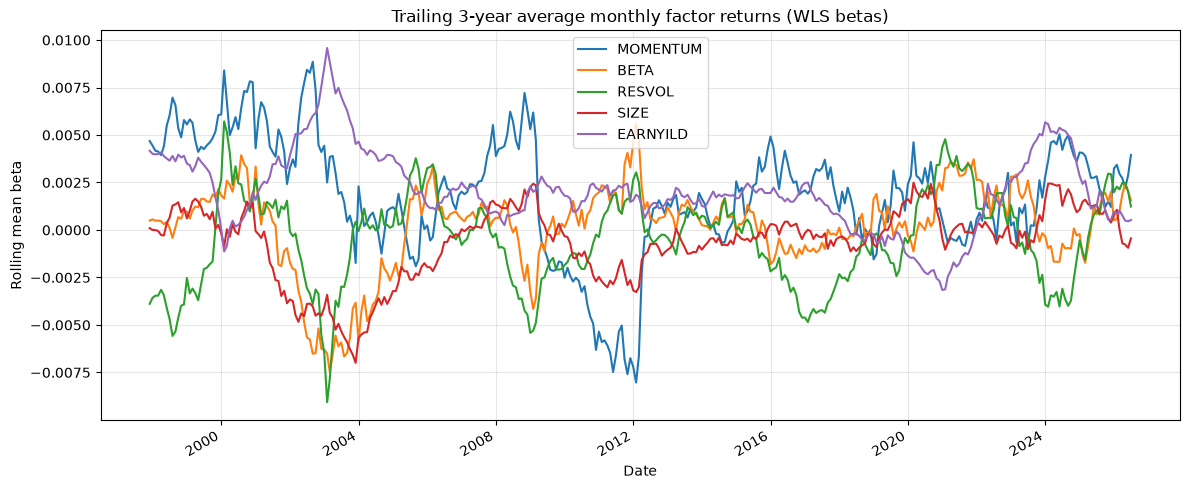

In [11]:
from_model = [f for f in PLOT_FACTORS if f in monthly_betas.columns]
extra_plot_factors = [f for f in PLOT_FACTORS if f not in FACTOR_COLUMNS]

plot_ts = monthly_betas.select(["date", *from_model])
if extra_plot_factors:
    extra_aggs = [
        wls_expr([factor], "coefficients", add_intercept=True)
        .struct.field(factor)
        .alias(factor)
        for factor in extra_plot_factors
    ]
    supplemental = (
        pl.scan_parquet(PARQUET_PATH)
        .filter(pl.col("country_gem4") == "USA")
        .with_columns((1.0 / pl.col("srisk").pow(2)).alias("regwt"))
        .group_by("date")
        .agg(*extra_aggs)
        .sort("date")
        .collect()
    )
    plot_ts = plot_ts.join(supplemental, on="date", how="full")

trailing = plot_ts.sort("date").select(
    "date",
    *[
        pl.col(f).rolling_mean(window_size=TRAIL_MONTHS, min_samples=TRAIL_MONTHS).alias(f)
        for f in PLOT_FACTORS
    ],
)

fig, ax = plt.subplots(figsize=(12, 5))
dates = trailing["date"].to_list()
for factor in PLOT_FACTORS:
    ax.plot(dates, trailing[factor], label=factor, linewidth=1.5)
ax.set_title(f"Trailing {TRAIL_MONTHS // 12}-year average monthly factor returns (WLS betas)")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling mean beta")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()